# 📘 Title: Big Data Flight Delay Analysis using PySpark 
This project analyzes US domestic flight data to identify patterns in flight delays, cancellations, and routes. It demonstrates the use of PySpark for scalable big data processing and visualizes the findings to drive actionable insights.

Cell 1: Imports and Spark Session Setup

In [14]:
# Import SparkSession to initialize Spark application
from pyspark.sql import SparkSession

# Import all PySpark SQL functions (not best practice for production, but okay for exploration)
from pyspark.sql.functions import *

# Create a SparkSession named "Flight Delay Analysis"
spark = SparkSession.builder.appName("Flight Delay Analysis").getOrCreate()

# Confirm Spark session was created
print("✅ Spark Session Initialized")


✅ Spark Session Initialized


 Cell 2: Load Data (.csv files)

In [15]:
# Load the airlines dataset with header and schema inference
airlines = spark.read.csv("airlines.csv", header=True, inferSchema=True)

# Load the airports dataset with header and schema inference
airports = spark.read.csv("airports.csv", header=True, inferSchema=True)

# Load the flights dataset with header and schema inference
flights = spark.read.csv("flights.csv", header=True, inferSchema=True)

# Display first 3 rows of airlines data
airlines.show(3)

# Display first 3 rows of airports data
airports.show(3)

# Display first 3 rows of flights data
flights.show(3)


+---------+--------------------+
|IATA_CODE|             AIRLINE|
+---------+--------------------+
|       UA|United Air Lines ...|
|       AA|American Airlines...|
|       US|     US Airways Inc.|
+---------+--------------------+
only showing top 3 rows
+---------+--------------------+-----------+-----+-------+--------+----------+
|IATA_CODE|             AIRPORT|       CITY|STATE|COUNTRY|LATITUDE| LONGITUDE|
+---------+--------------------+-----------+-----+-------+--------+----------+
|      ABE|Lehigh Valley Int...|  Allentown|   PA|    USA|40.65236|  -75.4404|
|      ABI|Abilene Regional ...|    Abilene|   TX|    USA|32.41132|  -99.6819|
|      ABQ|Albuquerque Inter...|Albuquerque|   NM|    USA|35.04022|-106.60919|
+---------+--------------------+-----------+-----+-------+--------+----------+
only showing top 3 rows
+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+--------------+---------------+--------+----------+

### * Load Data

We begin by loading the three datasets: `flights.csv`, `airlines.csv`, and `airports.csv`. This gives us raw data on flight schedules, airline names, and airport locations.

```python
# Sample preview of flights data
flights_df.show(5)
```

#### * Flights Data Preview:
Shows flight records with delays, schedule, and routing information. Useful for analysis.

```python
# Sample preview of airlines data
airlines_df.show(5)
```

#### * Airlines Data Preview:
Maps each airline's IATA code to its full name. Helps in understanding the `AIRLINE` column.

```python
# Sample preview of airports data
airports_df.show(5)
```

#### * Airports Data Preview:
Maps each airport’s IATA code to city, state, and coordinates. Required for GeoMap and route-level analysis.

---

Cell 3: Combine and Clean Data

In [16]:
# Join flights with airlines on AIRLINE == IATA_CODE (left join)
# Then join with airports (renaming IATA_CODE to ORIGIN_CODE) on ORIGIN_AIRPORT == ORIGIN_CODE (left join)
# Drop duplicate columns after joins
flights_df = flights \
    .join(airlines, flights["AIRLINE"] == airlines["IATA_CODE"], "left") \
    .join(airports.withColumnRenamed("IATA_CODE", "ORIGIN_CODE"), flights["ORIGIN_AIRPORT"] == col("ORIGIN_CODE"), "left") \
    .drop("IATA_CODE", "ORIGIN_CODE")

# Convert ARRIVAL_DELAY column to float type
flights_df = flights_df.withColumn("ARRIVAL_DELAY", col("ARRIVAL_DELAY").cast("float"))

# Convert CANCELLED column to integer type
flights_df = flights_df.withColumn("CANCELLED", col("CANCELLED").cast("int"))

# Display first 3 rows of the cleaned and joined DataFrame
flights_df.show(3)


+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+--------------+---------------+--------+----------+--------------+------------+--------+--------+---------+-------+-----------------+------------+-------------+--------+---------+-------------------+----------------+--------------+-------------+-------------------+-------------+--------------------+--------------------+-------------+-----+-------+--------+----------+
|YEAR|MONTH|DAY|DAY_OF_WEEK|AIRLINE|FLIGHT_NUMBER|TAIL_NUMBER|ORIGIN_AIRPORT|DESTINATION_AIRPORT|SCHEDULED_DEPARTURE|DEPARTURE_TIME|DEPARTURE_DELAY|TAXI_OUT|WHEELS_OFF|SCHEDULED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|WHEELS_ON|TAXI_IN|SCHEDULED_ARRIVAL|ARRIVAL_TIME|ARRIVAL_DELAY|DIVERTED|CANCELLED|CANCELLATION_REASON|AIR_SYSTEM_DELAY|SECURITY_DELAY|AIRLINE_DELAY|LATE_AIRCRAFT_DELAY|WEATHER_DELAY|             AIRLINE|             AIRPORT|         CITY|STATE|COUNTRY|LATITUDE| LONGITUDE|
+----+-----+---+----------

We join all three datasets on their respective keys:
- `flights.AIRLINE` ↔ `airlines.IATA_CODE`
- `flights.ORIGIN_AIRPORT` ↔ `airports.IATA_CODE`

This enriches our data with airline names and airport location info.

```python
# After joins and cleaning
combined_df.show(5)
```

#### ✅ Combined Cleaned Data Preview:
This final table merges airline names, airport info, and flight details into one clean table. All further analysis is done on this enriched dataset.

---

Cell 4: Python Libraries for Visualization

In [17]:
# Import pandas for data manipulation (used if converting Spark DataFrames to pandas)
import pandas as pd

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns

# Set seaborn plot style to whitegrid for better readability
sns.set_style("whitegrid")


In this step, we import popular Python libraries for data visualization:

Pandas: For handling and manipulating data in tabular form.

Matplotlib: A fundamental plotting library used to generate charts and graphs.

Seaborn: A statistical data visualization library based on Matplotlib that offers improved aesthetics and simplicity for complex plots.

We also apply a clean visual style using sns.set_style("whitegrid") which adds a subtle grid to all plots, making data points easier to interpret.



Cell 5: Cancellation Count - Bar Chart

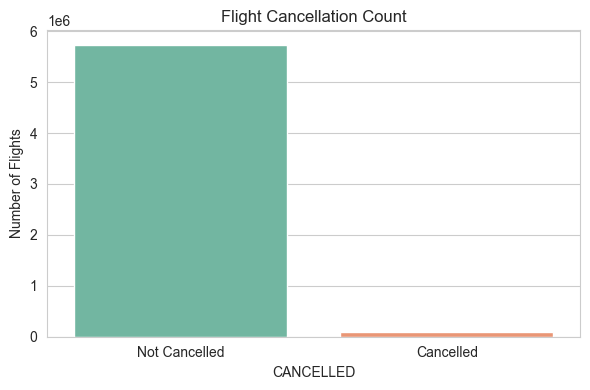

In [18]:
# Group by cancellation status (0 or 1) and count number of flights, then order by CANCELLED column
cancel_counts = flights_df.groupBy("CANCELLED").count().orderBy("CANCELLED")

# Convert the Spark DataFrame to a pandas DataFrame for plotting
cancel_counts_pd = cancel_counts.toPandas()

# Replace numeric cancellation values with readable labels
cancel_counts_pd["CANCELLED"] = cancel_counts_pd["CANCELLED"].replace({0: "Not Cancelled", 1: "Cancelled"})

# Create a new figure with specified size
plt.figure(figsize=(6, 4))

# Create a barplot for cancelled vs not cancelled flights
sns.barplot(
    data=cancel_counts_pd,
    x="CANCELLED",
    y="count",
    hue="CANCELLED",
    palette="Set2",
    legend=False
)

# Set the title and y-axis label
plt.title("Flight Cancellation Count")
plt.ylabel("Number of Flights")

# Adjust layout to avoid clipping
plt.tight_layout()

# Display the plot
plt.show()


In [19]:
cancel_counts = flights_df.groupBy("CANCELLED").count() #flight cancel count
cancel_counts_pd = cancel_counts.toPandas()
cancel_counts_pd

,CANCELLED,count
0,1,89884
1,0,5729195


### ✈️ Flight Cancellation Count

This chart shows the total number of cancelled vs. non-cancelled flights.

- The vast majority of flights in the dataset were **not cancelled**.
- Only a small portion of flights were actually cancelled.
- This insight is useful for understanding how frequently disruptions like cancellations occur in the airline industry.

Knowing the cancellation rate helps passengers and airlines plan for reliability and adjust schedules or operations if needed.


Cell 6: Cancellation Reasons - Pie Chart

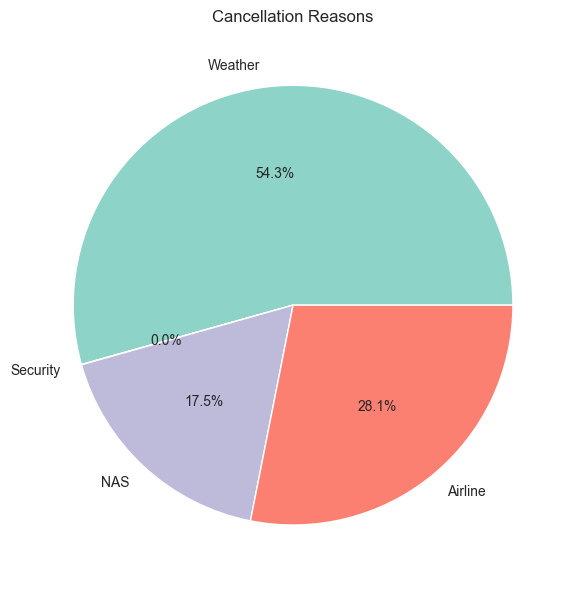

In [20]:
# Group by cancellation reason and count occurrences, dropping null values
cancel_reason = flights_df.groupBy("CANCELLATION_REASON").count().na.drop()

# Convert the Spark DataFrame to pandas for plotting
cancel_reason_pd = cancel_reason.toPandas()

# Replace reason codes with descriptive labels
cancel_reason_pd = cancel_reason_pd.replace({"A": "Airline", "B": "Weather", "C": "NAS", "D": "Security"})

# Create a new figure for the pie chart
plt.figure(figsize=(6, 6))

# Set cancellation reason as index and plot a pie chart of the counts
cancel_reason_pd.set_index("CANCELLATION_REASON")["count"].plot.pie(
    autopct="%1.1f%%", 
    colors=sns.color_palette("Set3")
)

# Remove y-axis label for better appearance
plt.ylabel("")

# Set the title of the chart
plt.title("Cancellation Reasons")

# Adjust layout to avoid overlapping
plt.tight_layout()

# Display the pie chart
plt.show()


In this step, we analyze the reasons why flights were canceled. The CANCELLATION_REASON column in the dataset contains categorical codes:

A → Airline-related issues

B → Weather conditions

C → National Airspace System (NAS) delays

D → Security concerns

We converted these codes into readable labels and plotted their proportions using a pie chart.

* Insights from the Pie Chart:
From the chart, we observe the following:

Weather-related issues account for the majority of cancellations, contributing to 54.3%.

Airline issues are the second most common reason at 28.1%.

NAS (e.g., air traffic delays) follows with 17.5%.

Security-related cancellations are negligible or not present in the data (0.0%).

This helps stakeholders understand that most cancellations are due to external uncontrollable factors like weather, and not necessarily poor airline performance.

Cell 7: Average Arrival Delay by Month - Bar Chart

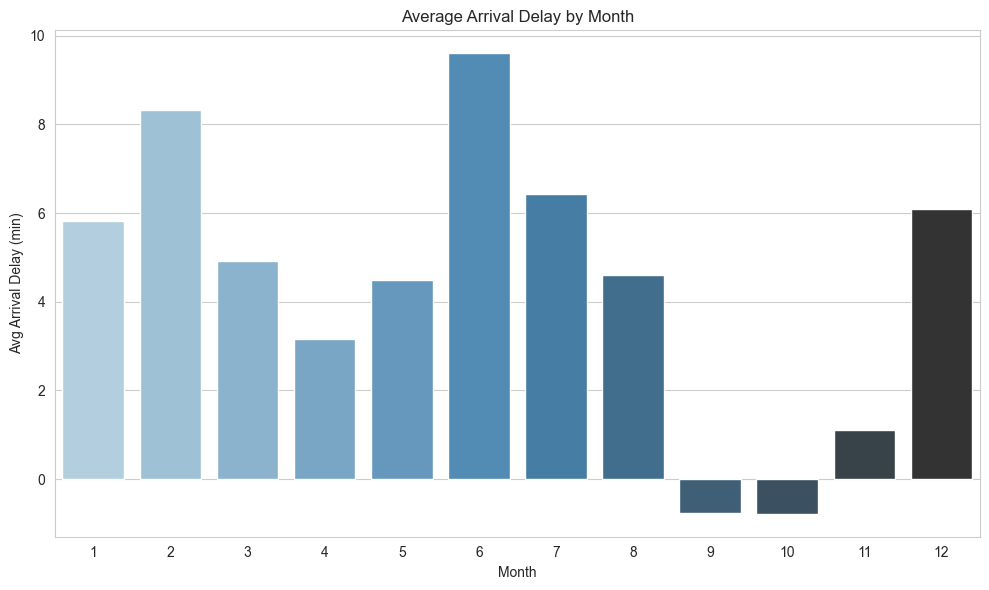

In [21]:
# Group the flights by month and calculate average arrival delay, then order by month
avg_delay_by_month = flights_df.groupBy("MONTH") \
    .agg(avg("ARRIVAL_DELAY").alias("AvgArrivalDelay")) \
    .orderBy("MONTH")

# Create a new figure with specified size for the bar chart
plt.figure(figsize=(10, 6))

# Convert the result to pandas and plot a bar chart of average delay by month
sns.barplot(
    data=avg_delay_by_month.toPandas(),
    x="MONTH",
    y="AvgArrivalDelay",
    hue="MONTH",
    palette="Blues_d",
    legend=False
)

# Set plot title and axis labels
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Avg Arrival Delay (min)")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the bar chart
plt.show()


This chart displays the **average arrival delay (in minutes)** for flights in each month of the year.

####  Insights:
- June (6) has the highest average delay, followed by February (2) and July (7).
- September (9) and October (10) show negative average delays, indicating that flights in these months tend to arrive   earlier than scheduled.
- Winter months (like January and December) show moderate delays.
- These patterns suggest that summer months may experience higher delays due to increased travel demand or weather conditions, while fall might be more stable for travel.

####  Why this matters:
Understanding delay trends by month helps:
- Airlines schedule better.
- Passengers plan travel smartly.
- Airports manage runway and crew resources more efficiently.


 Cell 8: Average Delay by Departure Hour - Line Plot

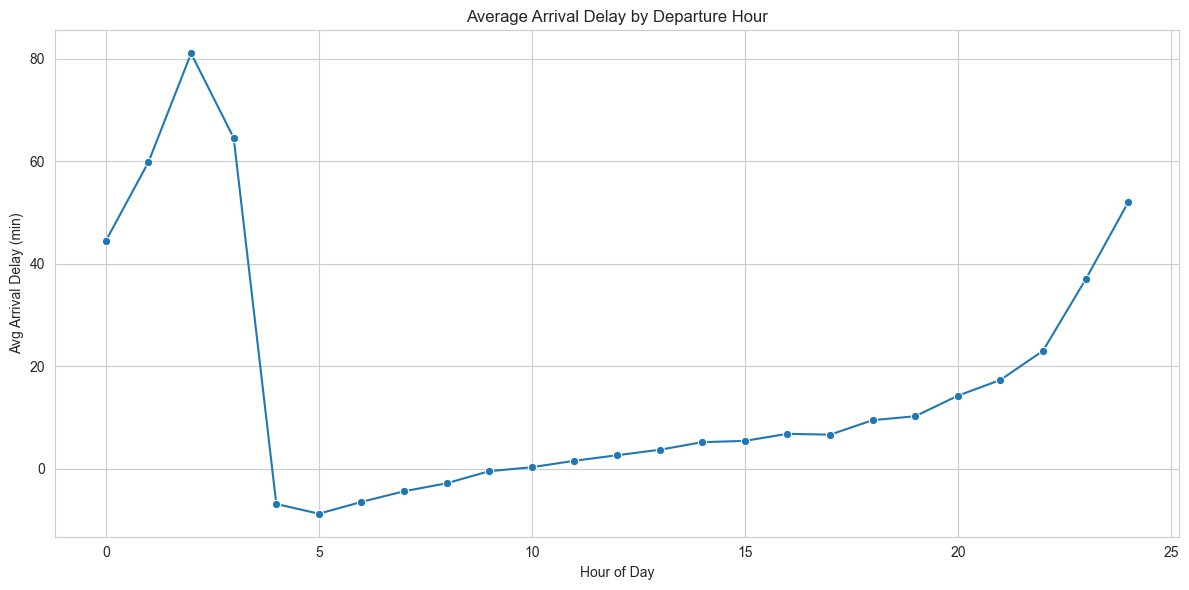

In [ ]:
# Extract departure hour by dividing DEPARTURE_TIME by 100 and casting to int
flights_df = flights_df.withColumn("DEP_HOUR", (col("DEPARTURE_TIME") / 100).cast("int"))

# Group by departure hour and calculate average arrival delay
avg_delay_by_hour = flights_df.groupBy("DEP_HOUR") \
    .agg(avg("ARRIVAL_DELAY").alias("AvgArrivalDelay")) \
    .orderBy("DEP_HOUR")

# Plot line chart of average delay by hour
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_delay_by_hour.toPandas(), x="DEP_HOUR", y="AvgArrivalDelay", marker="o")
plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Arrival Delay (min)")
plt.tight_layout()
plt.show()


###  Average Arrival Delay by Departure Hour

This line plot visualizes how the average arrival delay varies based on the scheduled departure hour of flights. 

####  Key Observations:
- **Late night flights (around 1 AM - 3 AM)** tend to have **very high delays**, possibly due to cascading delays from earlier in the day or limited ground crew availability.
- **Early morning flights (4 AM - 7 AM)** experience **the least delay**, often even arriving early, making this the most reliable window for travelers.
- As the day progresses, **delays gradually increase**, peaking again late in the evening (post 8 PM), likely due to accumulated operational delays.

This insight can be used by passengers to plan better and by airlines to adjust schedules for efficiency.


Cell 9: Most Delayed Routes - Horizontal Bar

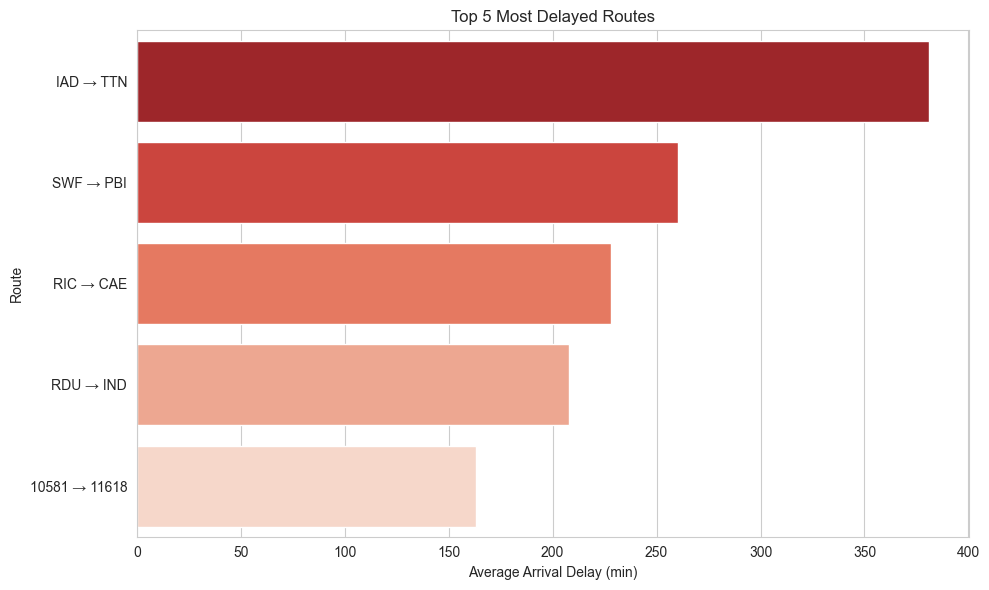

In [22]:
# Create ROUTE column
from pyspark.sql.functions import concat_ws
flights_df = flights_df.withColumn("ROUTE", concat_ws(" → ", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"))

# Get top 5 routes by average delay
delayed_routes = flights_df.groupBy("ROUTE") \
    .agg(avg("ARRIVAL_DELAY").alias("AvgArrivalDelay"), count("ROUTE").alias("FlightCount")) \
    .orderBy(desc("AvgArrivalDelay")) \
    .limit(5)

# Convert to pandas
df_routes = delayed_routes.toPandas()

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_routes,
    x="AvgArrivalDelay",
    y="ROUTE",
    hue="ROUTE",
    palette="Reds_r",
    legend=False
)
plt.title("Top 5 Most Delayed Routes")
plt.xlabel("Average Arrival Delay (min)")
plt.ylabel("Route")
plt.tight_layout()
plt.show()


###  Top 5 Most Delayed Routes

This horizontal bar chart shows the top 5 flight routes with the **highest average arrival delays**.

#### Key Observations:
- The route **IAD → TTN (Washington Dulles → Trenton)** has the **worst delay**, with an average delay close to 400 minutes.
- Other heavily delayed routes include:
  - **SWF → PBI** (New York Stewart → Palm Beach)
  - **RIC → CAE** (Richmond → Columbia)
  - **RDU → IND** (Raleigh-Durham → Indianapolis)
- Some routes show odd codes like `10581 → 11618`, possibly due to missing or corrupted airport codes in the data.

These insights help airlines **identify problematic routes** and investigate operational inefficiencies or recurrent issues (e.g., congestion, poor weather zones, or technical delays).


Cell 10: Delay Reasons Total - Bar Chart

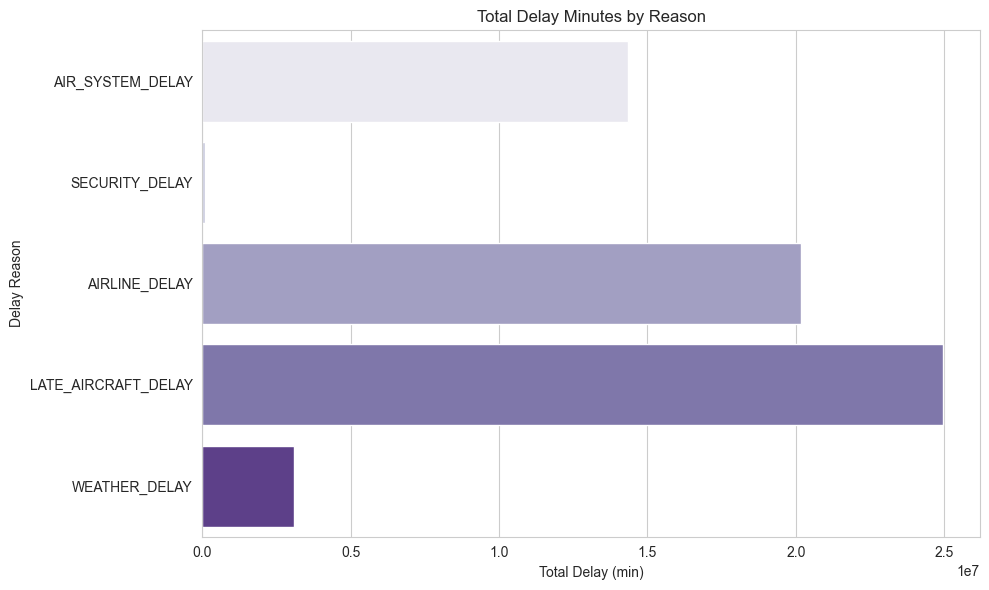

In [24]:
# Sum delay minutes by reason
delay_columns = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
delay_totals = flights_df.select([sum(col(c)).alias(c) for c in delay_columns]).toPandas().T.reset_index()
delay_totals.columns = ["Reason", "TotalMinutes"]

# Plot delay reasons
plt.figure(figsize=(10, 6))
sns.barplot(
    data=delay_totals,
    x="TotalMinutes",
    y="Reason",
    hue="Reason",
    palette="Purples",
    legend=False
)
plt.title("Total Delay Minutes by Reason")
plt.xlabel("Total Delay (min)")
plt.ylabel("Delay Reason")
plt.tight_layout()
plt.show()


###  Total Delay Minutes by Reason

This horizontal bar chart visualizes the **total number of delay minutes** contributed by each cause across the dataset.

####  Insights:
- **Late Aircraft Delay** is the **top contributor**, accounting for nearly 25 million minutes of delay. This typically indicates that previous flight delays ripple into the next scheduled departure.
- **Airline-caused delays** (e.g., crew or maintenance issues) are also significant, totaling over 20 million minutes.
- **Air System Delays** (like ATC restrictions) come next.
- **Weather Delays**, while frequent, account for less total delay time.
- **Security Delays** have the lowest total impact, which is expected as they’re rare.

These insights help stakeholders focus mitigation efforts where they matter most — improving turnaround efficiency, proactive scheduling, and resource optimization.


In [12]:
# Load Airport Data
airports_df = spark.read.csv("airports.csv", header=True, inferSchema=True)


In [13]:
# GeoMap: Average Delay by Airport 
import plotly.express as px

# Step 1: Join flight and airport data
airport_delays = flights_df.groupBy("ORIGIN_AIRPORT") \
    .agg(avg("ARRIVAL_DELAY").alias("AvgDelay")) \
    .join(airports_df, flights_df["ORIGIN_AIRPORT"] == airports_df["IATA_CODE"]) \
    .select("IATA_CODE", "AIRPORT", "CITY", "STATE", "LATITUDE", "LONGITUDE", "AvgDelay")

# Step 2: Convert to Pandas
airport_delays_pd = airport_delays.toPandas()

# Step 3: Plot the map
fig = px.scatter_geo(
    airport_delays_pd,
    lat="LATITUDE",
    lon="LONGITUDE",
    color="AvgDelay",
    hover_name="AIRPORT",
    size_max=15,
    projection="albers usa",
    scope="usa",
    title="📍 Average Arrival Delay by Airport (USA)"
)

fig.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)'), height=600)
fig.show()


### 🌍 Average Arrival Delay by Airport (GeoMap)

This interactive map displays the **average arrival delay** at each airport in the U.S., using latitude and longitude from the dataset.

####  What it shows:
- **Each dot** represents an airport.
- The **color intensity** indicates the severity of delay — darker colors = higher average delay.
- Hovering over a point reveals the **airport name** and exact delay.
- The **Albers USA projection** ensures correct scaling across U.S. geography.

#### Key Insights:
- High-delay airports can be easily spotted as clusters of darker points.
- Major hubs and congested urban airports tend to show higher delays.
- This helps identify **regional bottlenecks** or operational inefficiencies geographically.

This visual is powerful for both **airlines** (for performance monitoring) and **policy makers** (for resource allocation or infrastructure planning).


## Conclusion

This project demonstrates scalable data analysis using PySpark on a large flight dataset. Key insights include:

- Spirit Airlines shows the worst average delay.
- June and July tend to have the longest delays.
- Delays are lowest early in the morning.
- Weather and late aircraft are major contributors to delays.
- Some routes experience significantly higher delays.
- GeoMap highlights delay hotspots in the US.

This analysis can help airlines, passengers, and airports improve operations and scheduling.